# Cleaning Data Penjualan

# Pertanyaan Bisnis
1. Urutan 5 produk apa sajakah yang memiliki penjualan tertinggi?
2. Wilayah manakah yang memiliki permintaan tetinggi?
3. Bagaimana tren penjualan dalam rentang tahun?
4. Bagaimana proporsi kontribusi omset tiap kategori terhadap total penjualan?
5. Urutan wilayah mana yang menghasilkan omset tertinggi?


1. Import Library yang digunakan

In [ ]:
# load dataset
from google.colab import files

# data preprocessing
import pandas as pd
import numpy as np

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns

2. Load Dataset

In [ ]:
uploaded = files.upload()

Saving dataset_penjualan_kotor.csv to dataset_penjualan_kotor (3).csv


In [ ]:
sales_df = pd.read_csv('/content/dataset_penjualan_kotor.csv')
sales_df.head()

,transaction_id,product_id,product_name,region_id,region_name,date,quantity,price_per_unit,total_price
0,T9935,P001,Blender,R01,Jakarta,2024-06-22,3.0,456787,1370361.0
1,T4257,P001,Blender,R05,Makassar,2024-05-09,NaN,233326,933304.0
2,T3615,P005,Electric Kettle,R04,Medan,2024-01-02,2.0,671029,1342058.0
3,T2584,P004,Air Purifier,R03,Surabaya,27-01-2024,3.0,363032,1089096.0
4,T7201,P003,Vacuum Cleaner,R03,Surabaya,2024-05-17,5.0,477370,2386850.0


3. Data Understanding


In [ ]:
# cek kolom dataset
sales_df.head()

,transaction_id,product_id,product_name,region_id,region_name,date,quantity,price_per_unit,total_price
0,T9935,P001,Blender,R01,Jakarta,2024-06-22,3.0,456787,1370361.0
1,T4257,P001,Blender,R05,Makassar,2024-05-09,NaN,233326,933304.0
2,T3615,P005,Electric Kettle,R04,Medan,2024-01-02,2.0,671029,1342058.0
3,T2584,P004,Air Purifier,R03,Surabaya,27-01-2024,3.0,363032,1089096.0
4,T7201,P003,Vacuum Cleaner,R03,Surabaya,2024-05-17,5.0,477370,2386850.0


Insight
- Kolom transaction_id menyimpan nilai unik setiap transaksi.
- kolom product_id menyimpan kode dari setiap jenis produk yang kemudian namanya disimpan pada kolom product_name. ini artinya kolom product_id dan product_name merepresentasikan hal yang sama.
- kolom region_id menyimpan kode dari setiap kota di mana transaksi berlangsung, dan kemudian kolom region_name menyimpan nama kotanya. hal ini berarti kolom region_id dan region_name merepresentasikan hal yang sama.

In [ ]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  205 non-null    object 
 1   product_id      205 non-null    object 
 2   product_name    205 non-null    object 
 3   region_id       205 non-null    object 
 4   region_name     205 non-null    object 
 5   date            205 non-null    object 
 6   quantity        195 non-null    float64
 7   price_per_unit  205 non-null    int64  
 8   total_price     197 non-null    float64
dtypes: float64(2), int64(1), object(6)
memory usage: 14.5+ KB


insight
- Terdapat beberapa missing value pada kolom quantity dan total price
- beberapa tipe data belum sesuai.

In [ ]:
# cek data duplikat
sales_df.duplicated().sum()

np.int64(5)

In [ ]:
# hapus data duplikat
sales_df.drop_duplicates(inplace=True)
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  200 non-null    object 
 1   product_id      200 non-null    object 
 2   product_name    200 non-null    object 
 3   region_id       200 non-null    object 
 4   region_name     200 non-null    object 
 5   date            200 non-null    object 
 6   quantity        190 non-null    float64
 7   price_per_unit  200 non-null    int64  
 8   total_price     192 non-null    float64
dtypes: float64(2), int64(1), object(6)
memory usage: 15.6+ KB


In [ ]:
# mendeklarasikan kategorikal kolom dan numerikal kolom
cat_cols = ["transaction_id", "product_id", "product_name", "region_id", "region_name"]
num_cols = ["quantity", "price_per_unit", "total_price"]

In [ ]:
# cek keberagaman atau keunikan nilai setiap kolom kategorikal
sales_df[cat_cols].nunique()

,0
transaction_id,197
product_id,5
product_name,5
region_id,5
region_name,5


In [ ]:
duplicate_rows = sales_df[sales_df.duplicated('transaction_id', keep=False)]

duplicate_rows

,transaction_id,product_id,product_name,region_id,region_name,date,quantity,price_per_unit,total_price
34,T8179,P005,Electric Kettle,R03,Surabaya,2024-04-04,2.0,565962,1131924.0
56,T8612,P002,Rice Cooker,R05,Makassar,2024-02-01,4.0,252657,1010628.0
150,T2816,P004,Air Purifier,R05,Makassar,2024-01-30,4.0,634303,2537212.0
181,T2816,P003,Vacuum Cleaner,R02,Bandung,2024-06-08,NaN,327767,983301.0
186,T8612,P005,Electric Kettle,R03,Surabaya,2024-06-13,2.0,246489,492978.0
194,T8179,P001,Blender,R04,Medan,2024-01-08,3.0,738009,2214027.0


In [ ]:
sales_df.describe()

,quantity,price_per_unit,total_price
count,190.000000,200.000000,1.920000e+02
mean,3.078947,565265.280000,1.717351e+06
std,1.304887,222925.692653,1.025695e+06
min,1.000000,206182.000000,2.097670e+05
25%,2.000000,375112.750000,9.602925e+05
50%,3.000000,547114.000000,1.421631e+06
75%,4.000000,733547.250000,2.364444e+06
max,5.000000,999649.000000,4.733730e+06


Insigth
- Tidak ditemukan Outlier

## Cleaning

In [ ]:
cleaned_df = sales_df.copy()

In [ ]:
# menghapus kolom yang tidak digunakan
cleaned_df.drop(columns=['product_id', "region_id"], inplace=True)

In [ ]:
# memperbaiki tipe data

# membersihkan string tanggal
cleaned_df['date'] = (
    cleaned_df['date']
    .astype(str)
    .str.strip()
    .str.replace('\u00a0', '', regex=False)  # hapus spasi tak terlihat
)

# Parse utama: dd-mm-yyyy
parsed = pd.to_datetime(
    cleaned_df['date'],
    format='%d-%m-%Y',
    errors='coerce'
)

# Fallback: parsing fleksibel untuk yang gagal
mask = parsed.isna()

parsed.loc[mask] = pd.to_datetime(
    cleaned_df.loc[mask, 'date'],
    errors='coerce',
    dayfirst=True
)

# Assign balik
cleaned_df['date'] = parsed



cleaned_df['quantity'] = pd.to_numeric(cleaned_df['quantity'], errors='coerce').astype('Int64')
cleaned_df['price_per_unit'] = pd.to_numeric(cleaned_df['price_per_unit'], errors='coerce').astype('float64')


/tmp/ipython-input-386335816.py:21: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  parsed.loc[mask] = pd.to_datetime(


                quantity  price_per_unit  total_price
quantity        1.000000       -0.062353     0.651724
price_per_unit -0.062353        1.000000     0.617957
total_price     0.651724        0.617957     1.000000


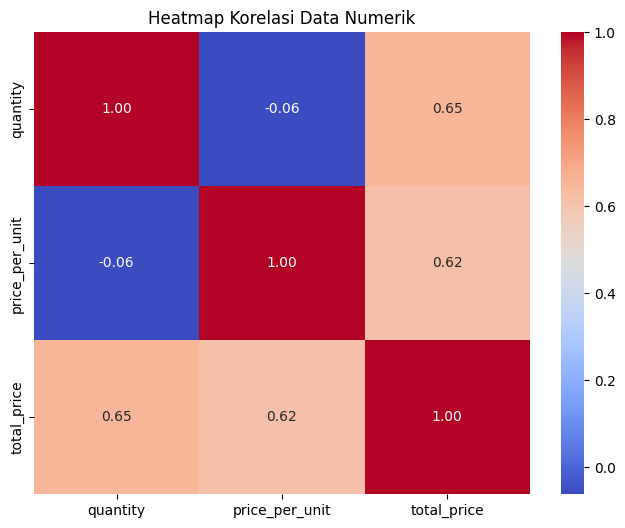

In [ ]:
# Ambil subset DataFrame
df_numeric = cleaned_df[num_cols].copy()

# Ubah kolom integer menjadi float agar bisa diisi mean
for col in df_numeric.select_dtypes(include=['Int64']):
    df_numeric[col] = df_numeric[col].astype(float)

# Isi null dengan mean
df_numeric = df_numeric.fillna(df_numeric.mean())

# Hitung korelasi
correlation_matrix = df_numeric.corr()

# Tampilkan matriks korelasi
print(correlation_matrix)

# Visualisasi dengan heatmap
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Heatmap Korelasi Data Numerik")
plt.show()

In [ ]:
# menampilkan semua baris yang memiliki nilai null
null_rows = cleaned_df[cleaned_df.isna().any(axis=1)]
null_rows

,transaction_id,product_name,region_name,date,quantity,price_per_unit,total_price
1,T4257,Blender,Makassar,2024-05-09,<NA>,233326.0,933304.0
31,T9565,Air Purifier,Jakarta,2024-01-21,5,458175.0,NaN
42,T7745,Rice Cooker,Bandung,2024-03-26,<NA>,632322.0,1264644.0
44,T2137,Vacuum Cleaner,Surabaya,2024-03-25,<NA>,433752.0,867504.0
46,T6139,Vacuum Cleaner,Bandung,2024-03-29,<NA>,478361.0,2391805.0
51,T6279,Electric Kettle,Makassar,2024-03-14,3,625800.0,NaN
82,T1745,Rice Cooker,Surabaya,2024-05-16,2,578411.0,NaN
93,T5102,Electric Kettle,Makassar,2024-04-20,4,659023.0,NaN
111,T5708,Air Purifier,Surabaya,2024-06-10,<NA>,767296.0,3069184.0
120,T2476,Rice Cooker,Jakarta,2024-04-03,1,523939.0,NaN


catatan :
- kolom quantity dan total_price adalah kolom yang saling berkorelasi.
- missing value yang ada pada kolom quantity dapat diatasi dengan imputasi hasil pembagian nilai pada kolom total_price dengan nilai pada kolom price_per_unit.
- missing value yang ada pada kolom total_price dapat diatasi dengan imputasi hasil perkalian nilai yang ada pada kolom quantity dengan nilai yang ada pada kolom price_per_unit
- baris yang memiliki nilai null di kedua kolom quanity dan total_price akan diatasi dengan menghapusnya

In [ ]:
# cek baris yang memiliki nilai null di kedua kolom quantity dan total_price
delete_null_rows = cleaned_df[cleaned_df['quantity'].isna() & cleaned_df['total_price'].isna()]
delete_null_rows

,transaction_id,product_name,region_name,date,quantity,price_per_unit,total_price
126,T4846,Vacuum Cleaner,Medan,2024-05-06,<NA>,346566.0,NaN


In [ ]:
# hapus baris yang memiliki nilai null di kedua kolom quantity dan total_price
cleaned_df.dropna(subset=['quantity', 'total_price'], how='all', inplace=True)

### Membersihkan data pada kolom Quantity



In [ ]:
quantity_null_rows = cleaned_df[cleaned_df['quantity'].isnull()]
quantity_null_rows

,transaction_id,product_name,region_name,date,quantity,price_per_unit,total_price
1,T4257,Blender,Makassar,2024-05-09,<NA>,233326.0,933304.0
42,T7745,Rice Cooker,Bandung,2024-03-26,<NA>,632322.0,1264644.0
44,T2137,Vacuum Cleaner,Surabaya,2024-03-25,<NA>,433752.0,867504.0
46,T6139,Vacuum Cleaner,Bandung,2024-03-29,<NA>,478361.0,2391805.0
111,T5708,Air Purifier,Surabaya,2024-06-10,<NA>,767296.0,3069184.0
154,T7626,Blender,Medan,2024-03-21,<NA>,657409.0,657409.0
155,T6928,Air Purifier,Surabaya,2024-06-07,<NA>,624707.0,624707.0
169,T8967,Blender,Medan,2024-02-24,<NA>,579404.0,2897020.0
181,T2816,Vacuum Cleaner,Bandung,2024-06-08,<NA>,327767.0,983301.0


In [ ]:
# mengisi data kolom quantity yang hilang dengan hasil pembagian total_price dengan price_per_uni dan pastikan hasilnya bilangan bulat
mask = (
    cleaned_df['quantity'].isna() &
    cleaned_df['total_price'].notna() &
    cleaned_df['price_per_unit'].notna()
)

cleaned_df.loc[mask, 'quantity'] = (
    cleaned_df.loc[mask, 'total_price'] /
    cleaned_df.loc[mask, 'price_per_unit']
).round().astype(int)

In [ ]:
# cek apakah setelah dibulatkan hasilnya tetap valid
check = (
    cleaned_df.loc[mask, 'quantity'] *
    cleaned_df.loc[mask, 'price_per_unit']
) == cleaned_df.loc[mask, 'total_price']

print(check.value_counts())

True    9
Name: count, dtype: Int64


### Membersihkan data pada kolom total_price

In [ ]:
total_price_null_rows = cleaned_df[cleaned_df['total_price'].isnull()]
total_price_null_rows

,transaction_id,product_name,region_name,date,quantity,price_per_unit,total_price
31,T9565,Air Purifier,Jakarta,2024-01-21,5,458175.0,NaN
51,T6279,Electric Kettle,Makassar,2024-03-14,3,625800.0,NaN
82,T1745,Rice Cooker,Surabaya,2024-05-16,2,578411.0,NaN
93,T5102,Electric Kettle,Makassar,2024-04-20,4,659023.0,NaN
120,T2476,Rice Cooker,Jakarta,2024-04-03,1,523939.0,NaN
151,T1897,Vacuum Cleaner,Makassar,2024-04-11,4,752530.0,NaN
197,T7340,Air Purifier,Surabaya,2024-02-17,3,461736.0,NaN


In [ ]:
# mengisi data kolom total_price yang hilang dengan hasil perkalian quantity dengan price_per_uni dan pastikan hasilnya bilangan bulat
mask = (
    cleaned_df['total_price'].isna() &
    cleaned_df['quantity'].notna() &
    cleaned_df['price_per_unit'].notna()
)

cleaned_df.loc[mask, 'total_price'] = (
    cleaned_df.loc[mask, 'quantity'] *
    cleaned_df.loc[mask, 'price_per_unit']
)

In [ ]:
# cek apakah inputasi data valid
check = (
    cleaned_df.loc[mask, 'quantity'] *
    cleaned_df.loc[mask, 'price_per_unit']
) == cleaned_df.loc[mask, 'total_price']

print(check.value_counts())

True    7
Name: count, dtype: Int64


In [ ]:
# cek apakah data sudah benar
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 199 entries, 0 to 199
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  199 non-null    object        
 1   product_name    199 non-null    object        
 2   region_name     199 non-null    object        
 3   date            199 non-null    datetime64[ns]
 4   quantity        199 non-null    Int64         
 5   price_per_unit  199 non-null    float64       
 6   total_price     199 non-null    float64       
dtypes: Int64(1), datetime64[ns](1), float64(2), object(3)
memory usage: 12.6+ KB


In [ ]:
cleaned_df[num_cols].describe()

,quantity,price_per_unit,total_price
count,199.0,199.000000,1.990000e+02
mean,3.075377,566364.271357,1.721668e+06
std,1.314006,222944.112451,1.019151e+06
min,1.0,206182.000000,2.097670e+05
25%,2.0,376119.000000,9.633880e+05
50%,3.0,549709.000000,1.423252e+06
75%,4.0,735034.500000,2.371913e+06
max,5.0,999649.000000,4.733730e+06


## Exploratory Data Analysis

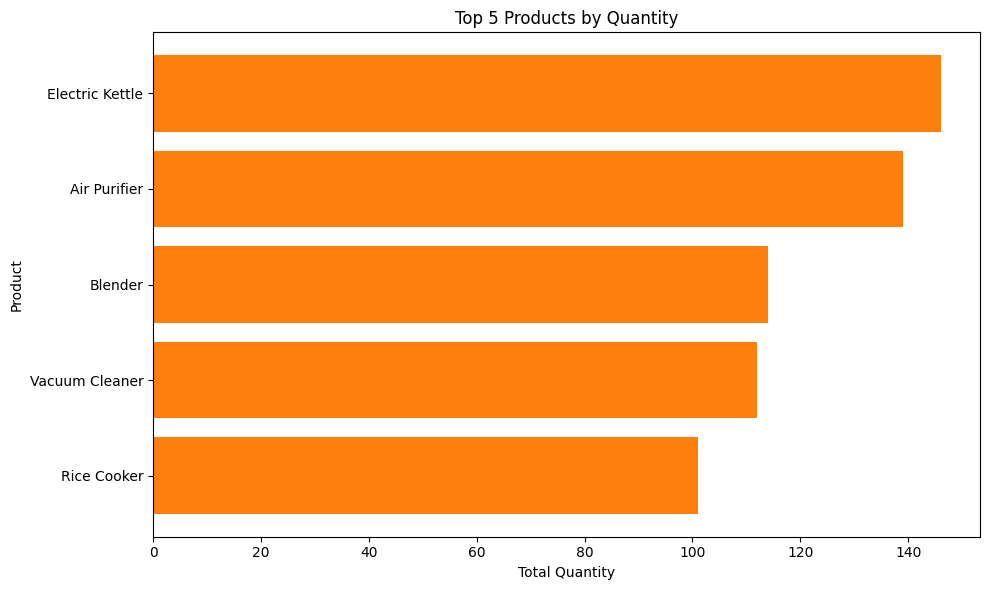

In [ ]:
total_per_product = cleaned_df.groupby('product_name')['quantity'].sum().reset_index()

# Ambil top 5 produk berdasarkan quantity
top5 = total_per_product.nlargest(5, 'quantity')
top5_sorted = top5.sort_values('quantity')

plt.figure(figsize=(10, 6))

plt.barh(
    top5_sorted['product_name'],
    top5_sorted['quantity'],
    color='tab:orange'
)

plt.xlabel('Total Quantity')
plt.ylabel('Product')
plt.title('Top 5 Products by Quantity')

plt.tight_layout()
plt.show()

# barang yang menghasilkan omset tertinggi

In [ ]:
omset_produk = (
    cleaned_df
    .groupby('product_name', as_index=False)
    .agg(total_omset=('total_price', 'sum'))
    .sort_values('total_omset', ascending=False)
)

omset_produk.head(10)


,product_name,total_omset
2,Electric Kettle,81703928.0
0,Air Purifier,74854026.0
1,Blender,70013946.0
4,Vacuum Cleaner,62970484.0
3,Rice Cooker,53069460.0


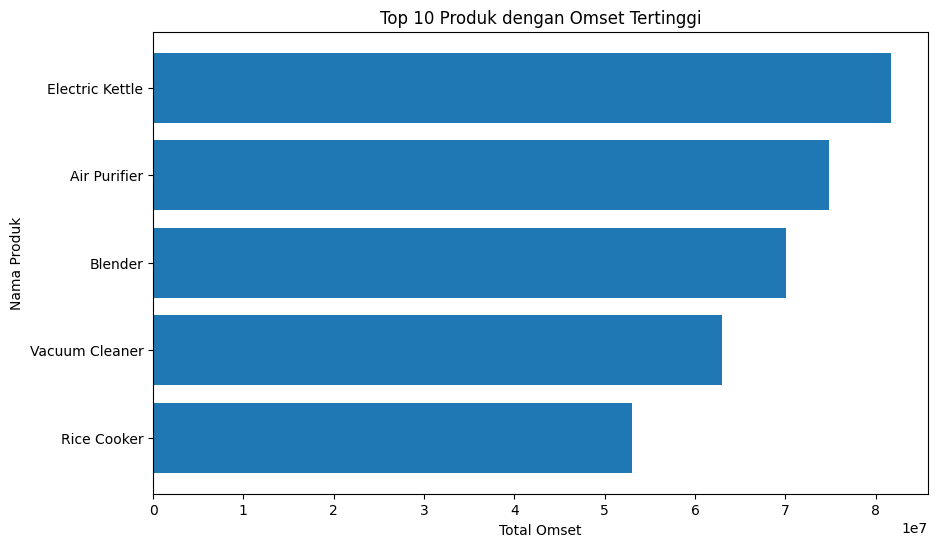

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(omset_produk['product_name'], omset_produk['total_omset'])
plt.xlabel('Total Omset')
plt.ylabel('Nama Produk')
plt.title('Top 10 Produk dengan Omset Tertinggi')
plt.gca().invert_yaxis()  # supaya omset terbesar di atas
plt.show()


### Wilayah dengan demand tertinggi

In [ ]:
wilayah_demand = (
    cleaned_df
    .groupby('region_name', as_index=False)
    .agg(
        total_quantity=('quantity', 'sum')
    )
    .sort_values(by='total_quantity', ascending=False)
)
wilayah_demand.head(5)



,region_name,total_quantity
1,Jakarta,140
4,Surabaya,140
2,Makassar,129
3,Medan,119
0,Bandung,84


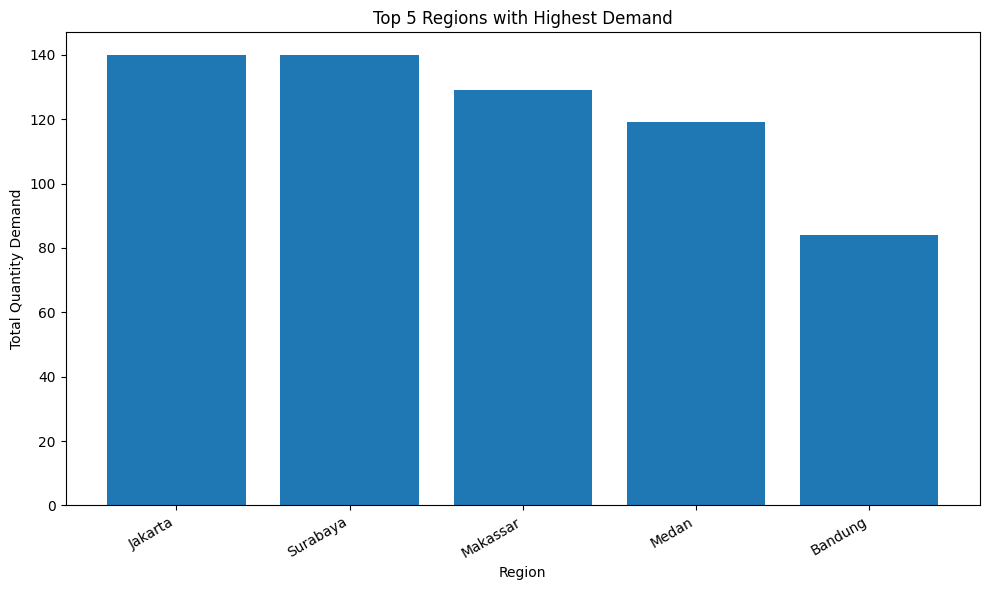

In [ ]:
top_wilayah = wilayah_demand.head(5)

plt.figure(figsize=(10, 6))

plt.bar(
    top_wilayah['region_name'],
    top_wilayah['total_quantity']
)

plt.xlabel('Region')
plt.ylabel('Total Quantity Demand')
plt.title('Top 5 Regions with Highest Demand')
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()


### Wilayah dengan omset tertinggi

In [ ]:
wilayah_omset = (
    cleaned_df
    .groupby('region_name', as_index=False)
    .agg(total_revenue=('total_price', 'sum'))
    .sort_values(by='total_revenue', ascending=False)
)

# Top 5 wilayah
wilayah_omset_top5 = wilayah_omset.head(5)

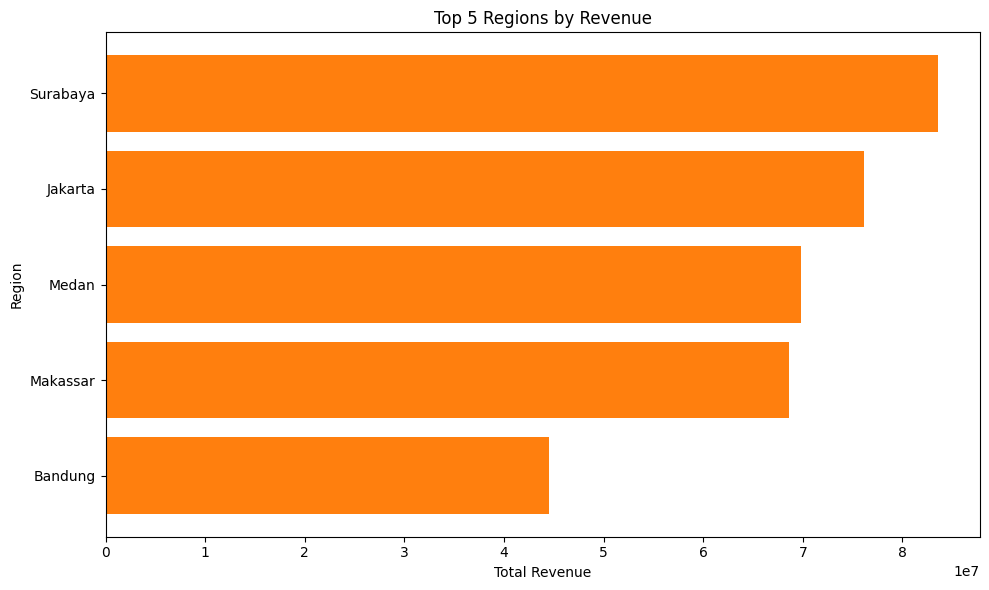

In [ ]:
plt.figure(figsize=(10,6))
plt.barh(wilayah_omset_top5['region_name'], wilayah_omset_top5['total_revenue'], color='tab:orange')
plt.xlabel('Total Revenue')
plt.ylabel('Region')
plt.title('Top 5 Regions by Revenue')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### Penjualan dalam rentang

In [ ]:
# 1. Pastikan date bertipe datetime
cleaned_df['date'] = pd.to_datetime(cleaned_df['date'])

# 2. Buat kolom bulan
cleaned_df['month'] = cleaned_df['date'].dt.to_period('M')

# 3. Groupby pakai kolom
monthly_product_sales = (
    cleaned_df
    .groupby(['month', 'product_name'], as_index=False)
    .agg(
        total_quantity=('quantity', 'sum'),
        total_revenue=('total_price', 'sum')
    )
)

# 4. Ubah period ke timestamp (untuk plotting)
monthly_product_sales['month'] = monthly_product_sales['month'].dt.to_timestamp()

monthly_product_sales.head()


,month,product_name,total_quantity,total_revenue
0,2024-01-01,Air Purifier,32,14630801.0
1,2024-01-01,Blender,28,19707717.0
2,2024-01-01,Electric Kettle,26,14642412.0
3,2024-01-01,Rice Cooker,40,19662832.0
4,2024-01-01,Vacuum Cleaner,15,8887709.0


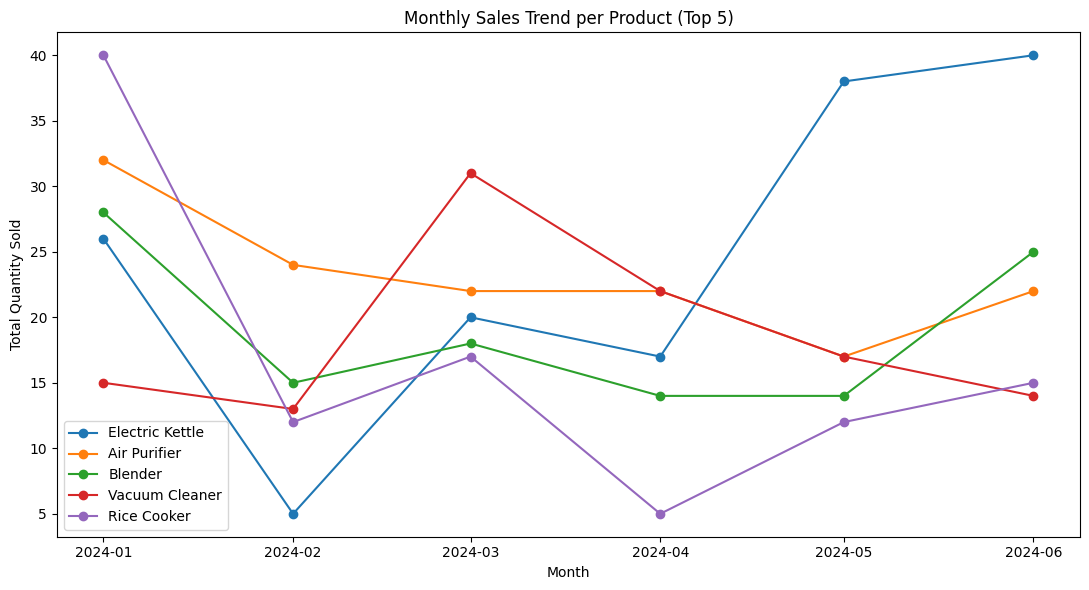

In [ ]:
top_products = (
    cleaned_df
    .groupby('product_name')['quantity']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

plt.figure(figsize=(11, 6))

for product in top_products:
    data = monthly_product_sales[monthly_product_sales['product_name'] == product]
    plt.plot(
        data['month'],
        data['total_quantity'],
        marker='o',
        label=product
    )

plt.xlabel('Month')
plt.ylabel('Total Quantity Sold')
plt.title('Monthly Sales Trend per Product (Top 5)')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
cleaned_df.to_csv('cleaned_df.csv', index=False)
